In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

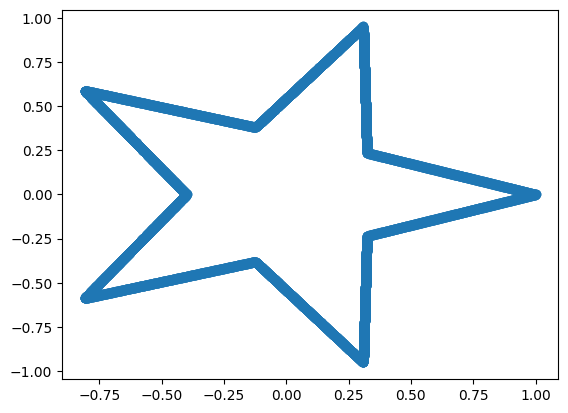

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [11]:
class Config:
    beta_min = 0.1
    beta_max = 20.0

    lr = 1e-3
    epochs = 3000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [5]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [6]:
# def sigma_t(t, config):
#     return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

# def g_t(t, config):
#     sigma = sigma_t(t, config)
#     c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

#     return sigma * c

def beta_t(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)


def int_beta_t(t, config):
    return config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2


def alpha_t(t, config):
    return torch.exp(-0.5 * int_beta_t(t, config))


def std_t(t, config):
    return torch.sqrt(1.0 - torch.exp(-int_beta_t(t, config)) + 1e-5)


def drift_t(x, t, config):
    return -0.5 * beta_t(t, config) * x


def diffusion_t(t, config):
    return torch.sqrt(beta_t(t, config))

In [7]:
class VPSDETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=config.batch_size,
            shuffle=True
        )

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            z = torch.randn_like(batch)

            alpha = alpha_t(t, self.config)
            std = std_t(t, self.config)

            x_t = alpha * batch + std * z

            pred_z = self.model(x_t, t)

            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Epoch {n}: loss = {loss:.6f}')

In [13]:
config = Config()
trainer = VPSDETrainer(config)

In [14]:
trainer.run()

Epoch 0: loss = 0.865033
Epoch 100: loss = 0.182376
Epoch 200: loss = 0.170143
Epoch 300: loss = 0.168630
Epoch 400: loss = 0.174216
Epoch 500: loss = 0.165857
Epoch 600: loss = 0.157913
Epoch 700: loss = 0.158838
Epoch 800: loss = 0.157543
Epoch 900: loss = 0.156806
Epoch 1000: loss = 0.156365
Epoch 1100: loss = 0.147987
Epoch 1200: loss = 0.153557
Epoch 1300: loss = 0.157867
Epoch 1400: loss = 0.147778
Epoch 1500: loss = 0.156995
Epoch 1600: loss = 0.148448
Epoch 1700: loss = 0.153234
Epoch 1800: loss = 0.157125
Epoch 1900: loss = 0.154835
Epoch 2000: loss = 0.148202
Epoch 2100: loss = 0.156416
Epoch 2200: loss = 0.157699
Epoch 2300: loss = 0.154163
Epoch 2400: loss = 0.146946
Epoch 2500: loss = 0.148964
Epoch 2600: loss = 0.141720
Epoch 2700: loss = 0.150306
Epoch 2800: loss = 0.147213
Epoch 2900: loss = 0.144961


In [34]:
@torch.no_grad()
def sample_vp_sde(model, config, n_samples=2000):
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(n_samples, 2, device=device)

    # eps = 1e-3
    # time_steps = torch.linspace(1.0, eps, config.num_timesteps, device=device)
    eps = config.t_eps
    time_steps = torch.linspace(1.0 - eps, eps, config.num_timesteps, device=device)
    dt = time_steps[0] - time_steps[1]

    for i, t_scalar in enumerate(time_steps):
        t = torch.full((n_samples, 1), t_scalar, device=device)

        beta = beta_t(t, config)
        g = diffusion_t(t, config)
        std = std_t(t, config)

        pred_z = model(x, t)
        score = -pred_z / std

        f = drift_t(x, t, config)
        rev_drift = f - (g ** 2) * score

        x_mean = x - rev_drift * dt

        if i < len(time_steps) - 1:
            noise = torch.randn_like(x)
            x = x_mean + g * torch.sqrt(dt) * noise
        else:
            x = x_mean

    return x.cpu()

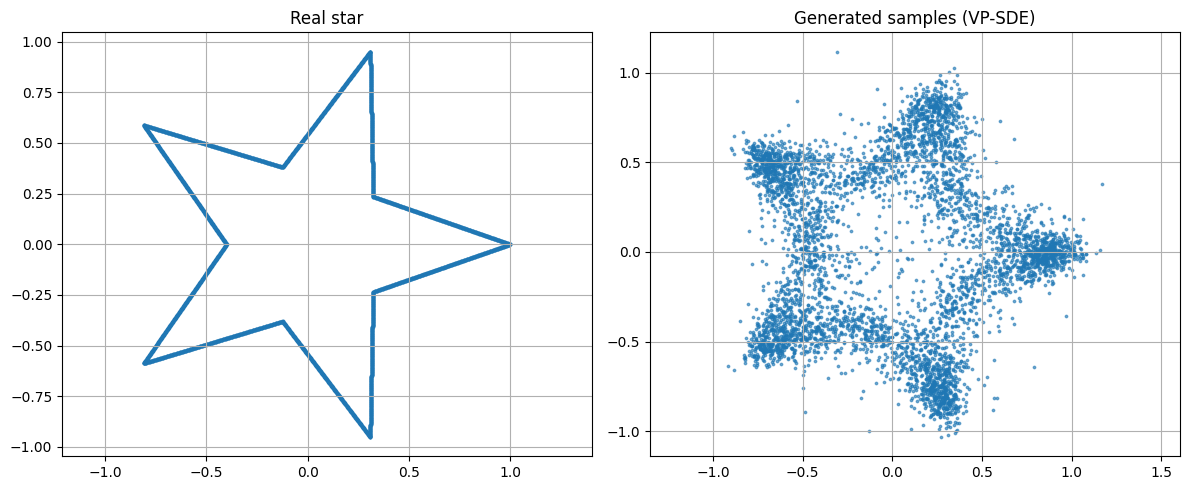

In [19]:
samples = sample_vp_sde(trainer.model, trainer.config, n_samples=5000).numpy()
real_data = trainer.data.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
plt.title('Generated samples (VP-SDE)')
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# plt.scatter(samples[:, 0], samples[:, 1])
# plt.show()

In [33]:
#новый trainer
class VPSDETrainer():
    def __init__(self, config, weighting='none'):
        self.config = config
        self.weighting = weighting
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=config.batch_size,
            shuffle=True
        )

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def get_loss_weights(self, t):
        if self.weighting == 'none':
            return torch.ones_like(t)
        elif self.weighting == 't':
            return t
        elif self.weighting == '1-t':
            return 1.0 - t
        elif self.weighting == 'std2':
            s = std_t(t, self.config)
            return s ** 2
        else:
            raise ValueError(f'Unknown weighting: {self.weighting}')

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            # t = torch.rand(batch.shape[0], 1, device=self.device)
            t = self.config.t_eps + (1.0 - 2.0 * self.config.t_eps) * torch.rand(batch.shape[0], 1, device=self.device)
            z = torch.randn_like(batch)

            alpha = alpha_t(t, self.config)
            std = std_t(t, self.config)

            x_t = alpha * batch + std * z
            pred_z = self.model(x_t, t)

            per_sample_loss = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            weights = self.get_loss_weights(t)
            loss = (weights * per_sample_loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        history = []

        for n in range(self.config.epochs):
            loss = self.train_epoch()
            history.append(loss)

            if n % 100 == 0:
                print(f'Epoch {n}: loss = {loss:.6f}')

        return history


In [22]:
config = Config()
trainer = VPSDETrainer(config, weighting='none')
history = trainer.run()

Epoch 0: loss = 0.881288
Epoch 100: loss = 0.173901
Epoch 200: loss = 0.179658
Epoch 300: loss = 0.175381
Epoch 400: loss = 0.180560
Epoch 500: loss = 0.163895
Epoch 600: loss = 0.178467
Epoch 700: loss = 0.167015
Epoch 800: loss = 0.156563
Epoch 900: loss = 0.149529
Epoch 1000: loss = 0.157239
Epoch 1100: loss = 0.147179
Epoch 1200: loss = 0.154427
Epoch 1300: loss = 0.172436
Epoch 1400: loss = 0.156351
Epoch 1500: loss = 0.160238
Epoch 1600: loss = 0.148635
Epoch 1700: loss = 0.156197
Epoch 1800: loss = 0.157374
Epoch 1900: loss = 0.159681
Epoch 2000: loss = 0.154435
Epoch 2100: loss = 0.146181
Epoch 2200: loss = 0.148042
Epoch 2300: loss = 0.152222
Epoch 2400: loss = 0.154879
Epoch 2500: loss = 0.150386
Epoch 2600: loss = 0.146126
Epoch 2700: loss = 0.149333
Epoch 2800: loss = 0.161534
Epoch 2900: loss = 0.154470


In [23]:
def run_experiment(weighting, epochs=1000, n_samples=5000):
    config = Config()
    config.epochs = epochs

    trainer = VPSDETrainer(config, weighting=weighting)
    history = trainer.run()
    samples = sample_vp_sde(trainer.model, config, n_samples=n_samples).numpy()

    return {
        'weighting': weighting,
        'trainer': trainer,
        'history': history,
        'samples': samples
    }

In [24]:
weightings = ['none', 't', '1-t', 'std2']
results = {}

for w in weightings:
    print(f'\nRunning experiment: {w}')
    results[w] = run_experiment(weighting=w, epochs=1000, n_samples=5000)


Running experiment: none
Epoch 0: loss = 0.858133
Epoch 100: loss = 0.174366
Epoch 200: loss = 0.174769
Epoch 300: loss = 0.167827
Epoch 400: loss = 0.170705
Epoch 500: loss = 0.150224
Epoch 600: loss = 0.163401
Epoch 700: loss = 0.168845
Epoch 800: loss = 0.154196
Epoch 900: loss = 0.172932

Running experiment: t
Epoch 0: loss = 0.424770
Epoch 100: loss = 0.022544
Epoch 200: loss = 0.021991
Epoch 300: loss = 0.022707
Epoch 400: loss = 0.022615
Epoch 500: loss = 0.021001
Epoch 600: loss = 0.021616
Epoch 700: loss = 0.022832
Epoch 800: loss = 0.022063
Epoch 900: loss = 0.021413

Running experiment: 1-t
Epoch 0: loss = 0.461305
Epoch 100: loss = 0.146350
Epoch 200: loss = 0.145255
Epoch 300: loss = 0.143791
Epoch 400: loss = 0.136491
Epoch 500: loss = 0.138222
Epoch 600: loss = 0.144232
Epoch 700: loss = 0.138261
Epoch 800: loss = 0.144174
Epoch 900: loss = 0.136062

Running experiment: std2
Epoch 0: loss = 0.623918
Epoch 100: loss = 0.034014
Epoch 200: loss = 0.034048
Epoch 300: loss =

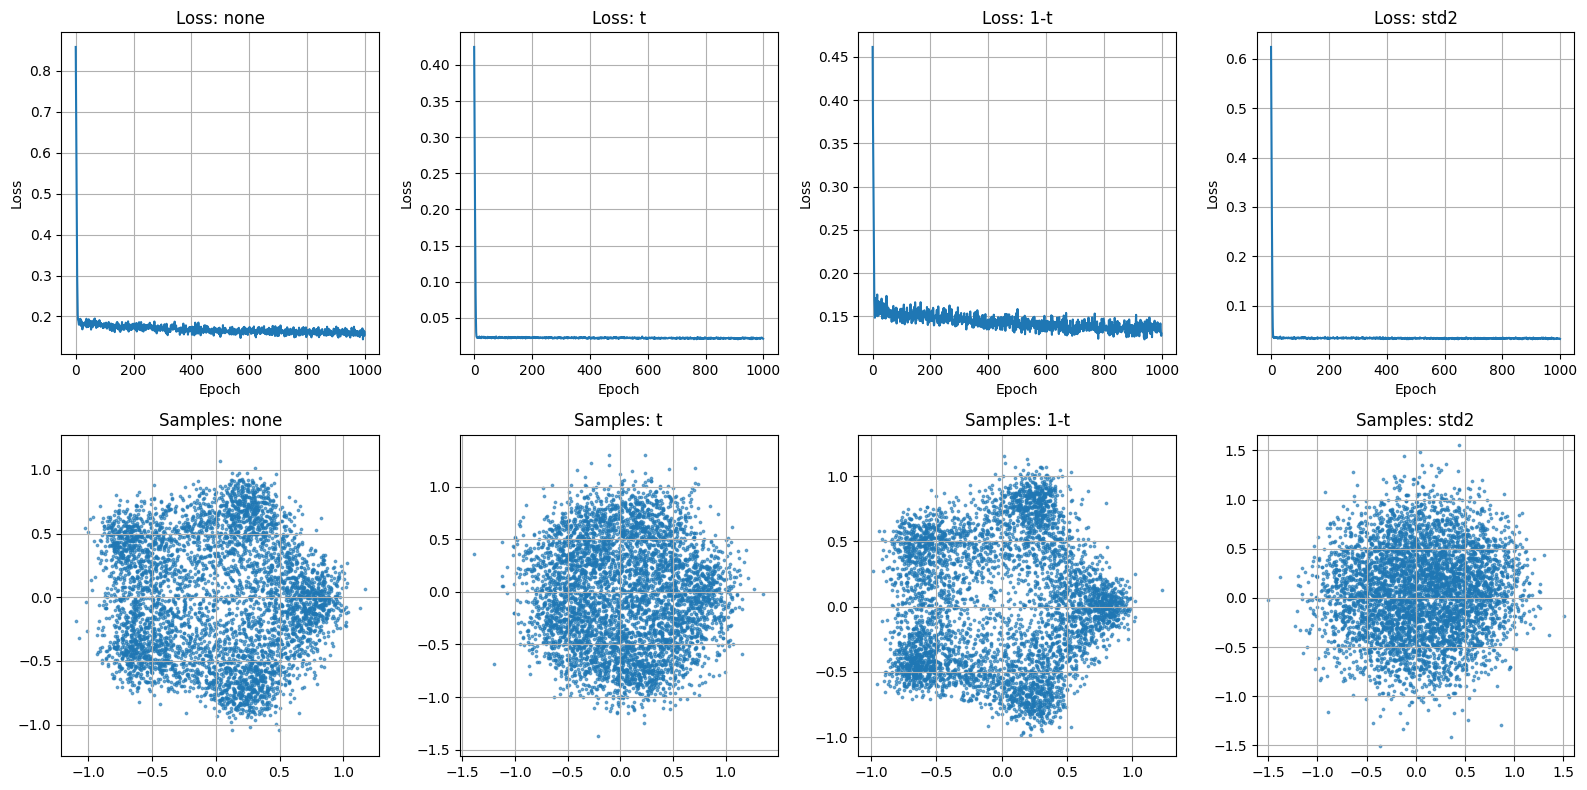

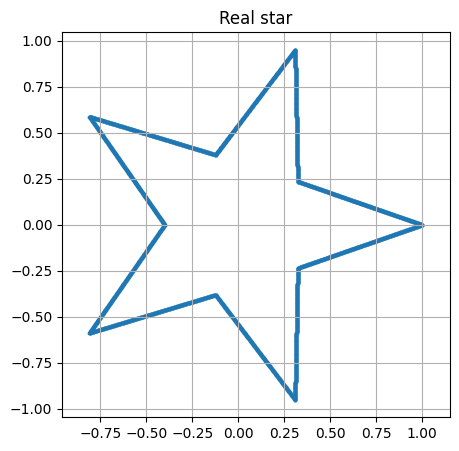

In [25]:
real_data = generate_star(n_samples=5000)

fig, axes = plt.subplots(2, len(weightings), figsize=(4 * len(weightings), 8))

for i, w in enumerate(weightings):
    history = results[w]['history']
    samples = results[w]['samples']

    axes[0, i].plot(history)
    axes[0, i].set_title(f'Loss: {w}')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].grid(True)

    axes[1, i].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
    axes[1, i].set_title(f'Samples: {w}')
    axes[1, i].axis('equal')
    axes[1, i].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)
plt.show()

лучший вариант `1 - t`, он дал самую узнаваемую звезду с лучами.
none тоже что-то выучил, но больше похож на кольцо из мод, чем на цельную звезду

Epoch 0: loss = 0.456963
Epoch 100: loss = 0.148446
Epoch 200: loss = 0.146283
Epoch 300: loss = 0.145089
Epoch 400: loss = 0.145371
Epoch 500: loss = 0.148673
Epoch 600: loss = 0.135810
Epoch 700: loss = 0.140243
Epoch 800: loss = 0.138048
Epoch 900: loss = 0.134827
Epoch 1000: loss = 0.136631
Epoch 1100: loss = 0.130626
Epoch 1200: loss = 0.136447
Epoch 1300: loss = 0.141270
Epoch 1400: loss = 0.122763
Epoch 1500: loss = 0.128336
Epoch 1600: loss = 0.132731
Epoch 1700: loss = 0.139107
Epoch 1800: loss = 0.142572
Epoch 1900: loss = 0.135343


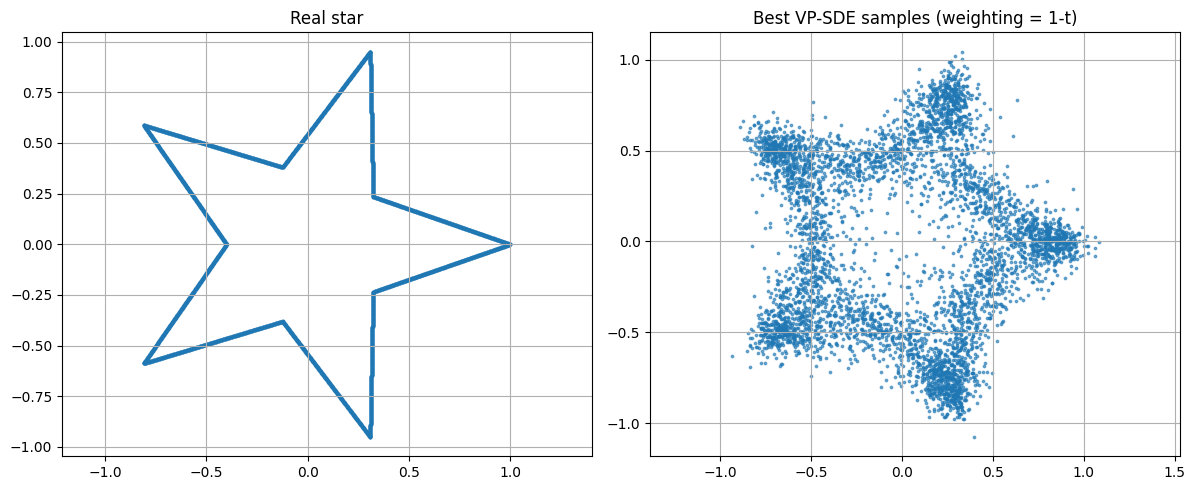

In [26]:
best_config = Config()
best_config.epochs = 2000

best_trainer = VPSDETrainer(best_config, weighting='1-t')
best_history = best_trainer.run()

best_samples = sample_vp_sde(best_trainer.model, best_config, n_samples=5000).numpy()
real_data = generate_star(n_samples=5000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(best_samples[:, 0], best_samples[:, 1], s=3, alpha=0.6)
plt.title('Best VP-SDE samples (weighting = 1-t)')
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()

были сравнены четыре варианта перевзвешивания лосса по времени: `none`, `t`, `1-t` и `std2`
основной вывод делался по визуальному качеству сгенерированной звезды
top-1: `1-t`: модель наиболее чётко восстановила лучи звезды и общую геометрию распределения
`t` и `std2` дали более сглаженное почти круговое распределение, то есть хуже восстановили детали формы.
значит, для этой задачи полезнее сильнее учитывать малые времена, когда зашумлённый sample ближе к данным и нужно точнее восстанавливать  структуру

In [32]:
class Config:
    beta_min = 0.1
    beta_max = 20.0

    lr = 1e-3
    epochs = 1000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

    schedule = 'linear'   # 'linear' or 'cosine'
    cosine_s = 0.008
    beta_clip = 20.0
    t_eps = 1e-3


def alpha_bar_t(t, config):
    if config.schedule == 'linear':
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        return torch.exp(-int_beta)

    elif config.schedule == 'cosine':
        s = config.cosine_s
        u = (t + s) / (1.0 + s)

        c0 = torch.cos(torch.tensor(0.5 * np.pi * s / (1.0 + s), device=t.device)) ** 2
        abar = torch.cos(0.5 * np.pi * u) ** 2 / c0
        return torch.clamp(abar, min=1e-5, max=1.0)

    else:
        raise ValueError(f'Unknown schedule: {config.schedule}')


def beta_t(t, config):
    if config.schedule == 'linear':
        beta = config.beta_min + t * (config.beta_max - config.beta_min)
        return torch.clamp(beta, min=1e-5, max=config.beta_clip)

    elif config.schedule == 'cosine':
        s = config.cosine_s
        u = (t + s) / (1.0 + s)
        beta = (np.pi / (1.0 + s)) * torch.tan(0.5 * np.pi * u)
        return torch.clamp(beta, min=1e-5, max=config.beta_clip)

    else:
        raise ValueError(f'Unknown schedule: {config.schedule}')


def alpha_t(t, config):
    return torch.sqrt(alpha_bar_t(t, config))


def std_t(t, config):
    abar = alpha_bar_t(t, config)
    return torch.sqrt(torch.clamp(1.0 - abar, min=1e-5, max=1.0))


def drift_t(x, t, config):
    return -0.5 * beta_t(t, config) * x


def diffusion_t(t, config):
    return torch.sqrt(beta_t(t, config))

In [28]:
schedules = ['linear', 'cosine']
schedule_results = {}

for sch in schedules:
    print(f'\nRunning schedule experiment: {sch}')

    config = Config()
    config.schedule = sch
    config.epochs = 1000

    trainer = VPSDETrainer(config, weighting='1-t')
    history = trainer.run()
    samples = sample_vp_sde(trainer.model, config, n_samples=5000).numpy()

    schedule_results[sch] = {
        'trainer': trainer,
        'history': history,
        'samples': samples
    }


Running schedule experiment: linear
Epoch 0: loss = 0.451149
Epoch 100: loss = 0.157296
Epoch 200: loss = 0.155192
Epoch 300: loss = 0.136918
Epoch 400: loss = 0.142501
Epoch 500: loss = 0.139942
Epoch 600: loss = 0.133079
Epoch 700: loss = 0.137973
Epoch 800: loss = 0.137699
Epoch 900: loss = 0.136968

Running schedule experiment: cosine
Epoch 0: loss = 0.472220
Epoch 100: loss = 0.257215
Epoch 200: loss = 0.231291
Epoch 300: loss = 0.240318
Epoch 400: loss = 0.231087
Epoch 500: loss = 0.231782
Epoch 600: loss = 0.227740
Epoch 700: loss = 0.226585
Epoch 800: loss = 0.225401
Epoch 900: loss = 0.217299


In [36]:
print('\nRunning fixed cosine experiment')

config = Config()
config.schedule = 'cosine'
config.epochs = 1000

trainer = VPSDETrainer(config, weighting='1-t')
history = trainer.run()
samples = sample_vp_sde(trainer.model, config, n_samples=5000).numpy()

schedule_results['cosine'] = {
    'trainer': trainer,
    'history': history,
    'samples': samples
}


Running fixed cosine experiment
Epoch 0: loss = 0.462463
Epoch 100: loss = 0.247517
Epoch 200: loss = 0.253458
Epoch 300: loss = 0.232245
Epoch 400: loss = 0.234185
Epoch 500: loss = 0.235593
Epoch 600: loss = 0.219066
Epoch 700: loss = 0.213507
Epoch 800: loss = 0.216739
Epoch 900: loss = 0.222992


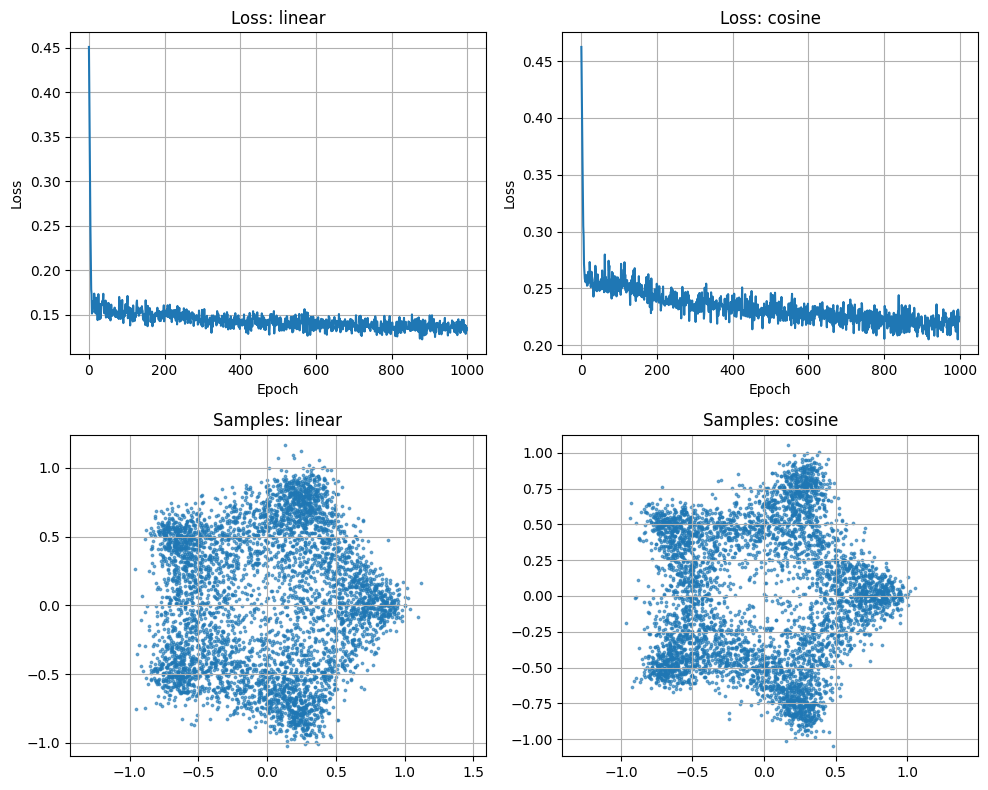

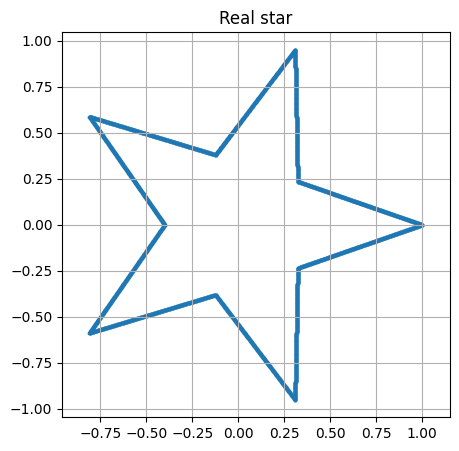

In [37]:
real_data = generate_star(n_samples=5000)

fig, axes = plt.subplots(2, len(schedules), figsize=(5 * len(schedules), 8))

for i, sch in enumerate(schedules):
    history = schedule_results[sch]['history']
    samples = schedule_results[sch]['samples']

    axes[0, i].plot(history)
    axes[0, i].set_title(f'Loss: {sch}')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].grid(True)

    axes[1, i].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
    axes[1, i].set_title(f'Samples: {sch}')
    axes[1, i].axis('equal')
    axes[1, i].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(real_data[:, 0], real_data[:, 1], s=3, alpha=0.6)
plt.title('Real star')
plt.axis('equal')
plt.grid(True)
plt.show()

In [31]:
cos_samples = schedule_results['cosine']['samples']

print('shape:', cos_samples.shape)
print('has nan:', np.isnan(cos_samples).any())
print('has inf:', np.isinf(cos_samples).any())
print('all finite:', np.isfinite(cos_samples).all())
print('min:', np.nanmin(cos_samples))
print('max:', np.nanmax(cos_samples))

shape: (5000, 2)
has nan: True
has inf: False
all finite: False
min: nan
max: nan


/tmp/ipykernel_731/4071695707.py:7: RuntimeWarning: All-NaN slice encountered
  print('min:', np.nanmin(cos_samples))
/tmp/ipykernel_731/4071695707.py:8: RuntimeWarning: All-NaN slice encountered
  print('max:', np.nanmax(cos_samples))


при linear звезда тоже получилась, но она более размытая и сильнее заполняется внутри. у cosine лучи видны четче, форма более аккуратная и ближе к исходной звезде, поэтому для этой задачи cosine schedule оказался удачнее